# EEG Signal Processing Workshop

Approx. 2-hour beginner workshop

This notebook follows the EEG lessons in [Neural Data Science in Python](https://neuraldatascience.io/) and keeps the code cells tied to their source notebooks. The flow is rearranged for teaching, but the live-code sections come from the NDS EEG materials rather than synthetic examples.

![An EEG system](EEG_Signal_Processing_Workshop_Final_files/banner.png)


## Table of Contents

1. **Part 1: EEG basics**
   - What is EEG?
   - Why choose EEG?
   - Time and frequency domains
   - Channels, montage, ground, and reference
   - Sampling rate, downsampling, and aliasing
2. **Part 2: Common EEG problems**
   - Blinks and eye movements
   - Muscle artifacts and environmental noise
   - Practical recording fixes
3. **Part 3: Preprocessing pipeline**
   - Common preprocessing steps
4. **Part 4: Hands-on with MNE-Python**
   - Read raw data and inspect MNE metadata
   - Filtering example
   - Events and epoching
   - Applying an ICA solution
5. **Part 5: ERP intuition and components**
   - ERP components
   - Averaging and re-referencing in MNE

This workshop follows the Neural Data Science EEG lessons, but the sequence is arranged for teaching: concepts first, then source-backed MNE examples, then ERP interpretation.


## Key Resources

Keep these open while working through the workshop:

- [Neural Data Science in Python](https://neuraldatascience.io/)
- [MNE documentation homepage](https://mne.tools/stable/index.html)
- [What is EEG?](https://neuraldatascience.io/eeg/about-eeg/)
- [Time and Frequency Domains](https://neuraldatascience.io/eeg/time-freq/)
- [Filtering EEG Data](https://neuraldatascience.io/eeg/erp-filtering/) and [Artifacts in EEG Data](https://neuraldatascience.io/eeg/erp-artifacts/)
- [Exploring MNE's data structure](https://neuraldatascience.io/eeg/mne-data-1/)
- [Segmentation into ERP epochs](https://neuraldatascience.io/eeg/erp-segmentation/) and [Averaging and Re-Referencing ERPs](https://neuraldatascience.io/eeg/erp-avg-reref/)
- [Event-Related Potentials (ERPs)](https://neuraldatascience.io/eeg/erps/) and [ERP Components](https://neuraldatascience.io/eeg/components/)


## Learning Goals

By the end of the workshop, learners should be able to:

- explain what EEG records and why it is useful for time-sensitive questions,
- distinguish time-domain from frequency-domain views of EEG,
- recognize common artifacts such as blinks, eye movements, and muscle activity,
- describe why filtering, ICA, re-referencing, epoching, and baseline correction are used,
- inspect `Raw`, `Epochs`, and `Evoked` objects in MNE-Python,
- connect event-locked EEG to ERPs and named ERP components.


## Part 1: EEG basics

The Neural Data Science EEG chapter starts by treating EEG as a continuous time-varying signal recorded from the scalp. The key beginner idea is that scalp EEG is not a direct readout of a single neuron or a single brain area; it is an aggregate signal shaped by large populations of neurons, the head as a conductor, and the reference used for measurement.


### What is EEG?

EEG, or electroencephalography, records electrical activity from the brain using electrodes placed on the scalp. Because the skull blurs electrical signals and the number of electrodes is tiny compared with the number of neurons in the brain, EEG reflects the coordinated activity of large neural populations rather than pinpoint activity from a single location.

Neural Data Science emphasizes two practical takeaways early:

- EEG is excellent when we care about **timing**.
- EEG is much weaker when we care about **precise spatial localization**.

![Sample raw EEG data](EEG_Signal_Processing_Workshop_Final_files/nds/eeg_raw_continuous.jpg)

*Source image: Neural Data Science in Python, [What is EEG?](https://neuraldatascience.io/eeg/about-eeg/).* 


### Why choose EEG?

EEG is widely used because it is non-invasive, relatively affordable, and sensitive to changes that unfold on the order of milliseconds. That makes it especially useful in cognitive neuroscience, clinical monitoring, BCIs, neurofeedback, and other settings where the timing of brain activity matters.

EEG is also a **continuous** signal. Unlike trial summary measures, EEG is recorded over time, so we can analyze it as a time series and then segment it around events of interest when we want ERP-style analyses.

Read more: [What is EEG?](https://neuraldatascience.io/eeg/about-eeg/)


### Time and frequency domains

Neural Data Science presents EEG in two complementary views:

- In the **time domain**, we look at voltage changing over time.
- In the **frequency domain**, we estimate how much power is present at different frequencies, often with an FFT.

![Continuous EEG in the time domain](EEG_Signal_Processing_Workshop_Final_files/nds/eeg_raw_continuous_30s.jpg)

*Source image: Neural Data Science in Python, [Time and Frequency Domains](https://neuraldatascience.io/eeg/time-freq/).* 

The important tradeoff is that time precision and frequency precision work against each other. Short windows tell us more about *when* something happened; longer windows improve estimation of *which frequencies* are present.

| Band | Approx. range (Hz) |
|---|---:|
| Delta | < 3 |
| Theta | 4-7 |
| Alpha | 8-15 |
| Mu | 8-13 |
| Beta | 15-30 |
| Gamma | > 30 |

Read more: [Time and Frequency Domains](https://neuraldatascience.io/eeg/time-freq/)


### Channels, montage, ground, and reference

A useful beginner correction is that an EEG channel is not an absolute brain voltage. It is a **difference in electrical potential** between one electrode and a reference.

`channel value = electrode potential - reference potential`

That means the reference matters for every waveform we see. Ground is different: it helps stabilize the recording electronics, while the reference helps define the voltage values that appear in the channels.

Standardized montages such as the 10-20 system make it possible to place electrodes in consistent scalp locations across participants and studies.

![EEG 10-20 system](EEG_Signal_Processing_Workshop_Final_files/eeg_10_20_system.jpg)

*Source image: Wikimedia Commons. This montage figure supports the workshop agenda alongside the NDS EEG lessons.*


### Sampling rate, downsampling, and aliasing

The sampling rate tells us how many measurements are stored per second. For example, 500 Hz means one sample every 2 ms. Downsampling can make EEG analysis faster and smaller, but Neural Data Science stresses the same warning used across EEG practice: if high-frequency content is left in the data before downsampling, it can fold into lower frequencies and create misleading structure.

![Aliasing illustration](EEG_Signal_Processing_Workshop_Final_files/nds/aliasing.png)

*Source image: Neural Data Science in Python, [Filtering EEG Data](https://neuraldatascience.io/eeg/erp-filtering/).* 

Rule of thumb: low-pass appropriately before downsampling.


## Part 2: Common EEG problems

EEG always contains a mixture of neural signal and non-neural signal. In the NDS materials, blinks, eye movements, muscle activity, and line noise are treated as core examples because they are large, common, and easy to mistake for meaningful brain activity if learners have not seen them before.


### Blinks and eye movements

Eye blinks tend to produce large frontal deflections, especially near channels such as Fp1, Fp2, and nearby frontal sites. Horizontal eye movements often create opposite-polarity patterns across left and right frontal electrodes.


### Muscle artifacts and environmental noise

Muscle contractions can contaminate scalp EEG with relatively high-frequency activity. Environmental electrical noise, including 50/60 Hz line noise, can also appear prominently in recordings. Both problems matter because the contaminating signals can be larger than the neural effects we care about.


### Artifact examples

<div style="display:flex; flex-direction:row; gap:18px; align-items:flex-start; justify-content:space-between;">
  <figure style="margin:0; text-align:center;">
    <img src="EEG_Signal_Processing_Workshop_Final_files/nds/eog_blink.png" alt="Blink artifact example" style="height:500px; width:auto;">
    <figcaption><em>Blink artifact example.</em><br></figcaption>
  </figure>
  <figure style="margin:0; text-align:center;">
    <img src="EEG_Signal_Processing_Workshop_Final_files/nds/eog_horiz.png" alt="Horizontal eye movement artifact example" style="height:500px; width:auto;">
    <figcaption><em>Horizontal eye movement example.</em><br></em></figcaption>
  </figure>
  <figure style="margin:0; text-align:center;">
    <img src="EEG_Signal_Processing_Workshop_Final_files/nds/eeg_muscle.png" alt="Muscle artifact example" style="height:500px; width:auto;">
    <figcaption><em>Muscle artifact example.</em><br></figcaption>
  </figure>
</div>


### Practical recording fixes

Good preprocessing helps, but it is always better to record cleaner data in the first place. Useful practical habits include:

- preparing electrodes carefully and checking impedance/contact,
- giving simple instructions about relaxing the face and minimizing unnecessary movement,
- reducing static and cable motion,
- keeping the participant comfortable so they do not generate extra muscle tension.


## Part 3: Preprocessing pipeline

A beginner-friendly EEG pipeline usually starts with inspecting the continuous recording, then moves through filtering and artifact handling before event-locked analysis. The exact order varies by lab and question, but the goal is consistent: preserve interpretable brain signal while reducing contamination.

### Common preprocessing steps

| Step | Why it is used |
|---|---|
| Notch filter | Reduces narrow-band line noise such as 50/60 Hz interference. |
| High-pass filter | Reduces very slow drift and can make some later steps more stable. |
| Low-pass filter | Reduces higher-frequency contamination such as muscle activity. |
| Band-pass filter | Keeps a target range by combining high-pass and low-pass choices. |
| ICA | Separates source-like components so obvious artifacts such as blinks can be removed. |
| Re-referencing | Changes the voltage baseline used for every EEG channel. |
| Epoching | Cuts continuous EEG into event-locked windows. |
| Baseline correction | Centers each epoch relative to a chosen pre-event interval. |

Source pages: [Filtering EEG Data](https://neuraldatascience.io/eeg/erp-filtering/), [Artifacts in EEG Data](https://neuraldatascience.io/eeg/erp-artifacts/), [Averaging and Re-Referencing ERPs](https://neuraldatascience.io/eeg/erp-avg-reref/), [Segmentation into ERP epochs](https://neuraldatascience.io/eeg/erp-segmentation/)


## Part 4: Hands-on with MNE-Python

MNE-Python is the main package used in the NDS EEG workflow. The most important data objects for this workshop are:

- `Raw`: continuous EEG data,
- `Epochs`: event-locked trial segments,
- `Evoked`: averages across epochs.

The code cells below are drawn from the NDS EEG notebooks and use the mirrored NDS sample files under `data/sub-001/`.


### Download sample files if needed

If you are running this notebook on a fresh machine, run the next cell once to fetch the four NDS sample files only when they are missing.


In [182]:
%%bash
u=https://raw.githubusercontent.com/neural-data-science/NESC_3505_textbook/master/7-eeg/data/sub-001
d=./data/sub-001
mkdir -p "$d" && cd "$d"
for f in sub-001-{raw,filt-raw,epo}.fif sub-001-ica.fif; do [ -f "$f" ] || curl -L -O "$u/$f"; done


### Read raw data and inspect MNE metadata

In [183]:
import mne
mne.set_log_level('error')
import matplotlib.pyplot as plt
import numpy as np

In [184]:
# Read the Raw Data
raw = mne.io.read_raw_fif('data/sub-001/sub-001-raw.fif', preload=True)
raw.set_montage('easycap-M1')                                  

<Raw | sub-001-raw.fif, 16 x 408640 (817.3 s), ~49.9 MB, data loaded>

In [185]:
raw.info

<Info | 10 non-empty values
 bads: []
 ch_names: Fp1, F3, F7, C3, P3, TP9, Fz, Cz, Fp2, F4, F8, C4, P4, TP10, Pz, Oz
 chs: 16 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2015-01-20 13:15:58 UTC
 meas_id: 4 items (dict)
 nchan: 16
 projs: []
 sfreq: 500.0 Hz
>

In [186]:
raw.info.keys()

dict_keys(['file_id', 'events', 'hpi_results', 'hpi_meas', 'subject_info', 'device_info', 'helium_info', 'hpi_subsystem', 'proc_history', 'meas_id', 'experimenter', 'description', 'proj_id', 'proj_name', 'meas_date', 'utc_offset', 'sfreq', 'highpass', 'lowpass', 'line_freq', 'gantry_angle', 'chs', 'dev_head_t', 'ctf_head_t', 'dev_ctf_t', 'dig', 'bads', 'ch_names', 'nchan', 'projs', 'comps', 'acq_pars', 'acq_stim', 'custom_ref_applied', 'xplotter_layout', 'kit_system_id'])

In [187]:
raw.info['ch_names']

['Fp1',
 'F3',
 'F7',
 'C3',
 'P3',
 'TP9',
 'Fz',
 'Cz',
 'Fp2',
 'F4',
 'F8',
 'C4',
 'P4',
 'TP10',
 'Pz',
 'Oz']

In [188]:
raw.load_data()

<Raw | sub-001-raw.fif, 16 x 408640 (817.3 s), ~49.9 MB, data loaded>

In [189]:
print(raw._data.shape)

(16, 408640)


In [190]:
raw.info['sfreq']

500.0

In [191]:
scan_durn = raw._data.shape[1] / raw.info['sfreq']
print('Duration of EEG recording = ', scan_durn, 's, or', round(scan_durn / 60, 2), 'min.')

Duration of EEG recording =  817.28 s, or 13.62 min.


In [192]:
raw.get_data(picks='Oz', tmin=1.0, tmax=1.1)

array([[-3.32371535e-05, -3.56695929e-05, -3.70699696e-05,
        -3.73843960e-05, -3.61347964e-05, -3.37185687e-05,
        -3.24967200e-05, -3.43886186e-05, -3.84356292e-05,
        -4.12323722e-05, -4.10137923e-05, -3.98413434e-05,
        -4.01963986e-05, -4.22024501e-05, -4.45214045e-05,
        -4.58859187e-05, -4.59046117e-05, -4.50669050e-05,
        -4.43964713e-05, -4.46733242e-05, -4.59191067e-05,
        -4.77312796e-05, -4.90899787e-05, -4.91470097e-05,
        -4.88115996e-05, -4.93814205e-05, -5.04391395e-05,
        -5.07022562e-05, -5.01242385e-05, -4.98433810e-05,
        -5.00698792e-05, -5.00764560e-05, -4.94547598e-05,
        -4.80297813e-05, -4.60116137e-05, -4.45004237e-05,
        -4.49821231e-05, -4.72950692e-05, -4.82656245e-05,
        -4.62170343e-05, -4.42591434e-05, -4.39658883e-05,
        -4.31154970e-05, -4.12371413e-05, -3.99026661e-05,
        -3.87107654e-05, -3.58946615e-05, -3.21113418e-05,
        -3.00001925e-05, -3.01028090e-05]])

### Filtering

#### Notch Filter

In [193]:
raw.compute_psd().plot();

/Users/luka/PycharmProjects/visual-evoked-potentials/.venv/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


/Users/luka/PycharmProjects/visual-evoked-potentials/.venv/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


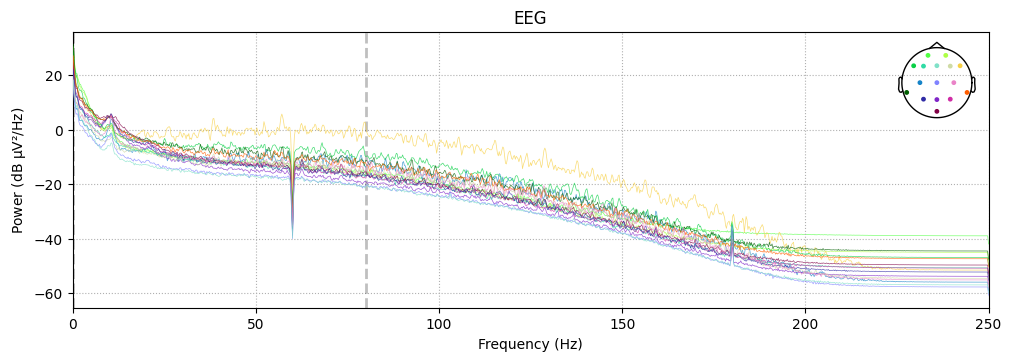

In [194]:
# Notch filter settings
notch_freq = 60.0  # frequency to be removed from the signal

raw_notch = raw.copy().notch_filter(notch_freq)
raw_notch.compute_psd().plot()

Alternative notch filtering example:

- [DSS Line Filter using MEEGKit](https://nbara.github.io/python-meegkit/auto_examples/example_dss_line.html)

#### Bandpass filter

In [195]:
# Band-pass filter
low_cut = 0.1
hi_cut  = 60

raw_filt = raw_notch.copy().filter(low_cut, hi_cut)

/Users/luka/PycharmProjects/visual-evoked-potentials/.venv/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


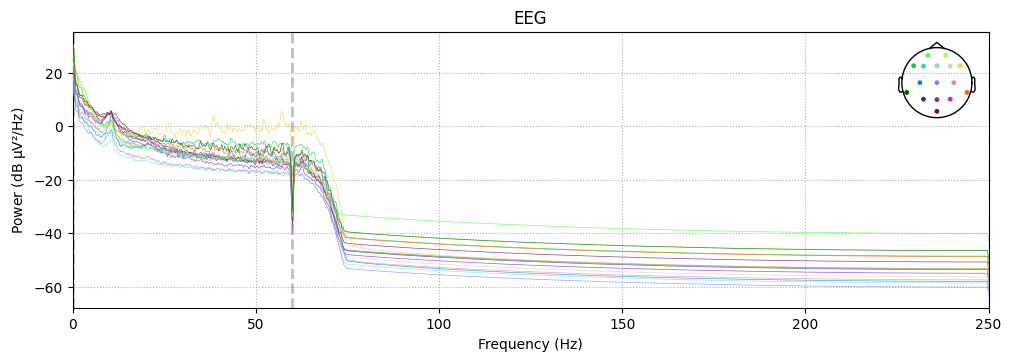

In [196]:
raw_filt.compute_psd().plot()

#### Independent Component Analysis (ICA)

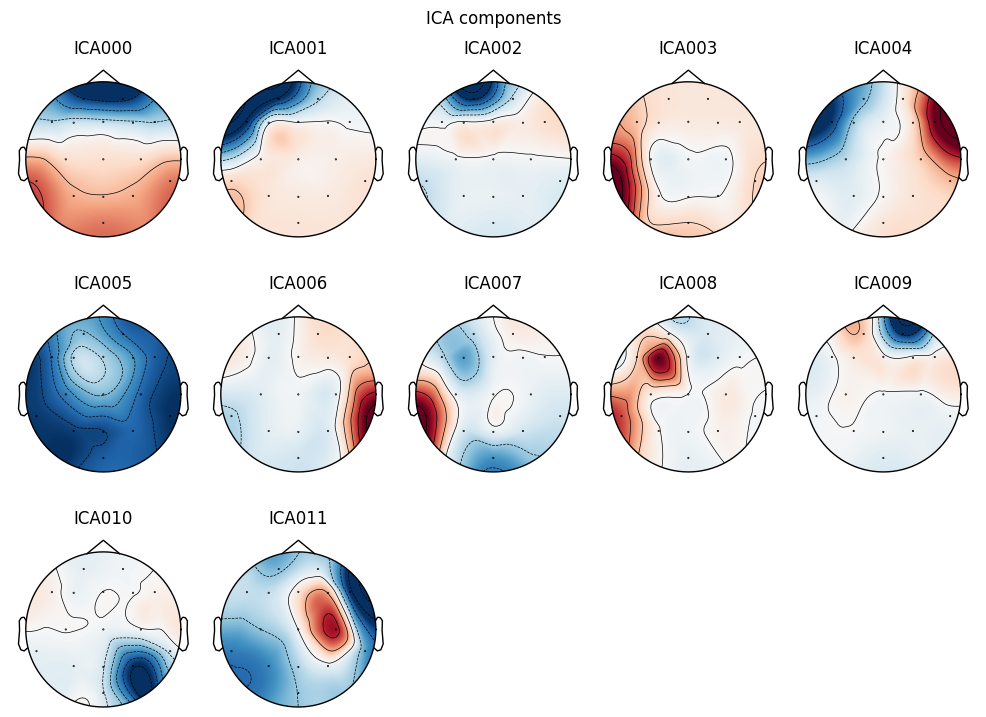

In [199]:
# Fit ICA
ica = mne.preprocessing.ICA(n_components=0.99,
                            random_state=42,
                            )
ica.fit(raw_filt, decim=3)
ica.plot_components();
# ica.fit(raw_filt[~reject_log.bad_epochs], decim=3)

# apply the ICA decomposition (excluding the marked ICs) to the epochs
# ica.plot_components();
# epochs_postica = ica.apply(epochs.copy())
# epochs_postica

Read more about ICA:
- [The Power of Independent Component Analysis (ICA) on Real-World Applications – EEG Example](https://towardsdatascience.com/the-power-of-independent-component-analysis-ica-on-real-world-applications-egg-example-48df336a1bd8/)

### Events and epoching

The segmentation notebook turns a filtered continuous recording into event-locked data. The workflow is: extract events, build an event dictionary, create epochs, and inspect the result.


In [ ]:
raw_filt = mne.io.read_raw_fif('data/sub-001/sub-001-filt-raw.fif')
raw_filt.set_montage('easycap-M1')                                  

<Raw | sub-001-filt-raw.fif, 16 x 408640 (817.3 s), ~30 kB, data not loaded>

In [ ]:
events, events_dict = mne.events_from_annotations(raw_filt)

In [ ]:
events_dict

{np.str_('Comment/actiCAP Data On'): 1,
 np.str_('Stimulus/S  1'): 2,
 np.str_('Stimulus/S  2'): 3,
 np.str_('Stimulus/S  3'): 4,
 np.str_('Stimulus/S  4'): 5,
 np.str_('Stimulus/S  5'): 6,
 np.str_('Stimulus/S  7'): 7,
 np.str_('Stimulus/S101'): 8,
 np.str_('Stimulus/S102'): 9,
 np.str_('Stimulus/S111'): 10,
 np.str_('Stimulus/S112'): 11,
 np.str_('Stimulus/S201'): 12,
 np.str_('Stimulus/S202'): 13,
 np.str_('Stimulus/S211'): 14,
 np.str_('Stimulus/S212'): 15}

In [ ]:
event_mapping = {'PicOnset':1, 'RespPrompt':2, 'CorResp':3, 'IncorResp':4, 'RespFeedback':5, 'unused':7,          
                 'Match/A':111, 'Match/B':211, 'Match/C':112, 'Match/D':212,
                 'Mismatch/A':101, 'Mismatch/B':201, 'Mismatch/C':102, 'Mismatch/D':202
                }

In [ ]:
# swap keys and values in event_mapping
event_mapping = {v:k for k,v in event_mapping.items()}
event_mapping

{1: 'PicOnset',
 2: 'RespPrompt',
 3: 'CorResp',
 4: 'IncorResp',
 5: 'RespFeedback',
 7: 'unused',
 111: 'Match/A',
 211: 'Match/B',
 112: 'Match/C',
 212: 'Match/D',
 101: 'Mismatch/A',
 201: 'Mismatch/B',
 102: 'Mismatch/C',
 202: 'Mismatch/D'}

In [ ]:
# make a new dictionary to map experiment labels to MNE's event codes
event_id = {}

for key, value in events_dict.items():
    # select only the keys in `events_dict` that match this string
    if 'Stimulus/S' in key:
        # strip the leading text from the key to get the numerical event code
        orig_event_code = int(key.split('/S')[1])
        # "value" is the integer event code that MNE assigned to each event code it found in the data
        # we map this value to a key that corresponds to the original event code, 
        # and add this key:value pair to event_id
        event_id[event_mapping[orig_event_code]] = value
        
event_id 

{'PicOnset': 2,
 'RespPrompt': 3,
 'CorResp': 4,
 'IncorResp': 5,
 'RespFeedback': 6,
 'unused': 7,
 'Mismatch/A': 8,
 'Mismatch/C': 9,
 'Match/A': 10,
 'Match/C': 11,
 'Mismatch/B': 12,
 'Mismatch/D': 13,
 'Match/B': 14,
 'Match/D': 15}

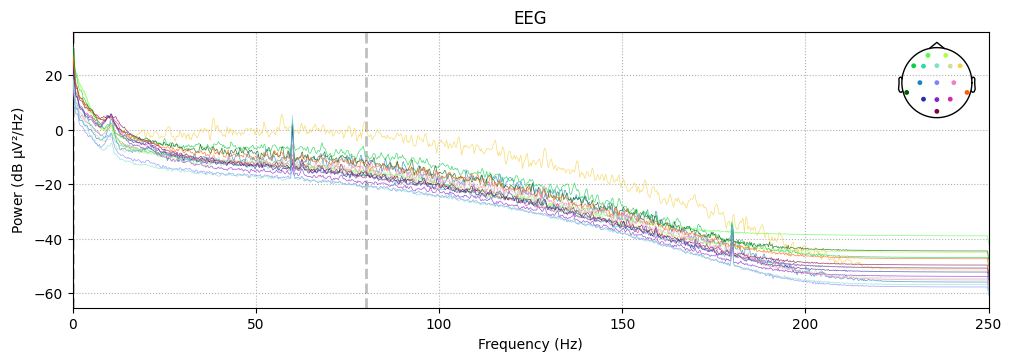

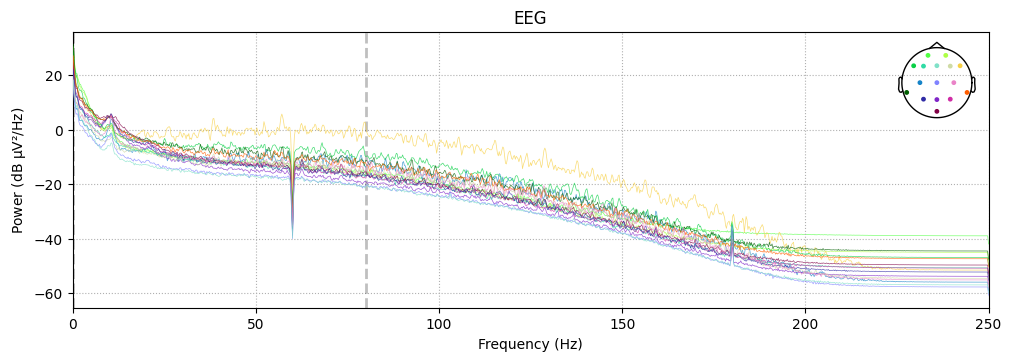

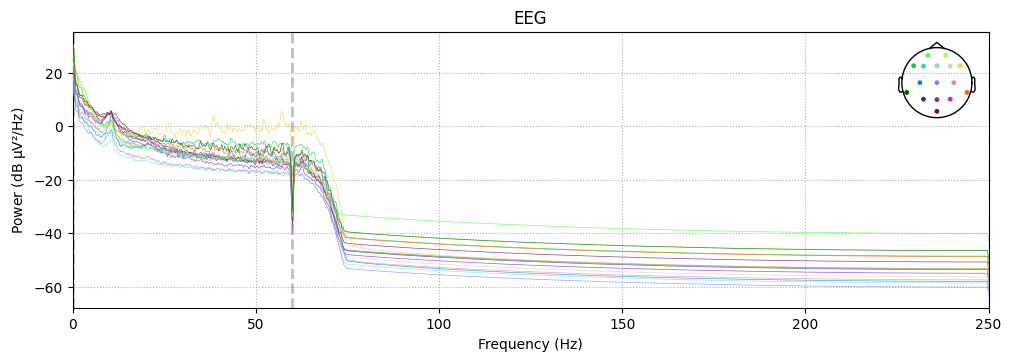

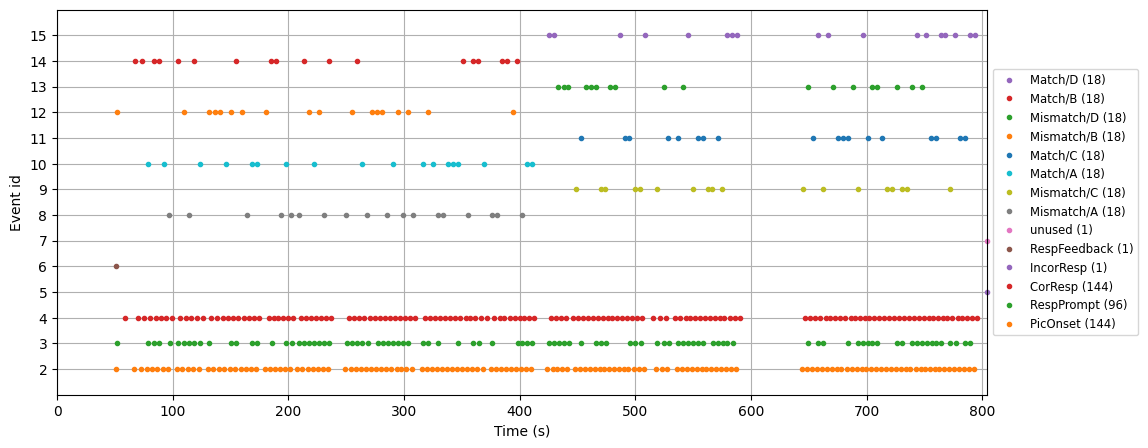

In [ ]:
fig, ax = plt.subplots(figsize=[15, 5])

mne.viz.plot_events(events, raw_filt.info['sfreq'],  
                    event_id=event_id,                    
                    axes=ax)
plt.show();

In [ ]:
# Epoching settings
tmin =  -.100  # start of each epoch (in sec)
tmax =  1.000  # end of each epoch (in sec)
baseline = (None, 0)

# Create epochs
epochs = mne.Epochs(raw_filt,
                    events, event_id,
                    tmin, tmax,
                    baseline=baseline, 
                    preload=True
                   ) 

In [ ]:
epochs

<Epochs | 531 events (all good), -0.1 – 1 s (baseline -0.1 – 0 s), ~35.7 MB, data loaded,
 'PicOnset': 144
 'RespPrompt': 96
 'CorResp': 144
 'IncorResp': 1
 'RespFeedback': 1
 'unused': 1
 'Mismatch/A': 18
 'Mismatch/C': 18
 'Match/A': 18
 'Match/C': 18
 and 4 more events ...>

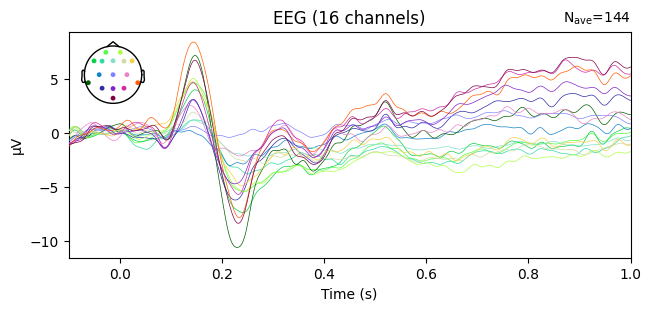

In [ ]:
epochs['Match', 'Mismatch'].average().plot();

## Part 5: ERP intuition and components

ERPs are short stretches of EEG that are time-locked to events of interest and then typically averaged across many trials. The key logic is that activity unrelated to the event should vary from trial to trial, while event-related responses should line up in time and become more visible after averaging.

Now, we will segment the data into epochs, and apply artifact correction to the segments, based on the ICA decomposition that we performed in the previous step, as well as using the AutoReject algorithm to automatically detect and remove bad epochs and channels that ICA may not fix.

![ERP trial averaging](EEG_Signal_Processing_Workshop_Final_files/nds/erp_trial_averaging.png)

*Source image: Neural Data Science in Python, [Event-Related Potentials (ERPs)](https://neuraldatascience.io/eeg/erps/).* 


### ERP components



![N170 component example](EEG_Signal_Processing_Workshop_Final_files/nds/N170_component.png)

*Source image: Neural Data Science in Python, [ERP Components](https://neuraldatascience.io/eeg/components/).* 


### Averaging and re-referencing in MNE

These cells come from the NDS re-referencing lesson. They create condition averages, compare ERPs across channels, and show how changing the reference changes the appearance of the data.


In [ ]:


epochs = mne.read_epochs('data/sub-001/sub-001-epo.fif', preload=True).set_montage('easycap-M1')

In [ ]:
conditions = ['Match', 'Mismatch']

evokeds = {c:epochs[c].average() for c in conditions}

evokeds    

{'Match': <Evoked | '0.25 × Match/A + 0.25 × Match/C + 0.25 × Match/B + 0.25 × Match/D' (average, N=72), -0.1 – 1 s, baseline -0.1 – 0 s, 16 ch, ~99 kB>,
 'Mismatch': <Evoked | '0.25 × Mismatch/A + 0.24 × Mismatch/C + 0.25 × Mismatch/B + 0.25 × Mismatch/D' (average, N=71), -0.1 – 1 s, baseline -0.1 – 0 s, 16 ch, ~99 kB>}

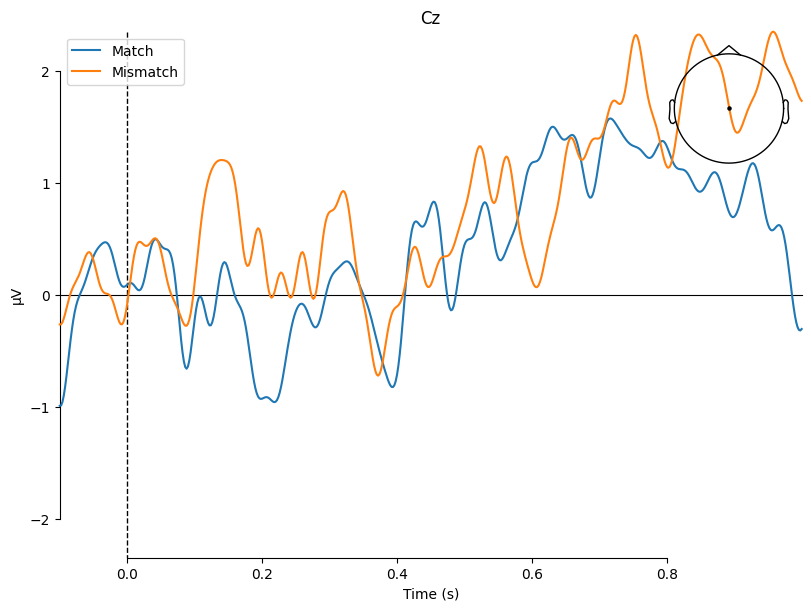

In [ ]:
mne.viz.plot_compare_evokeds(evokeds, picks='Cz');

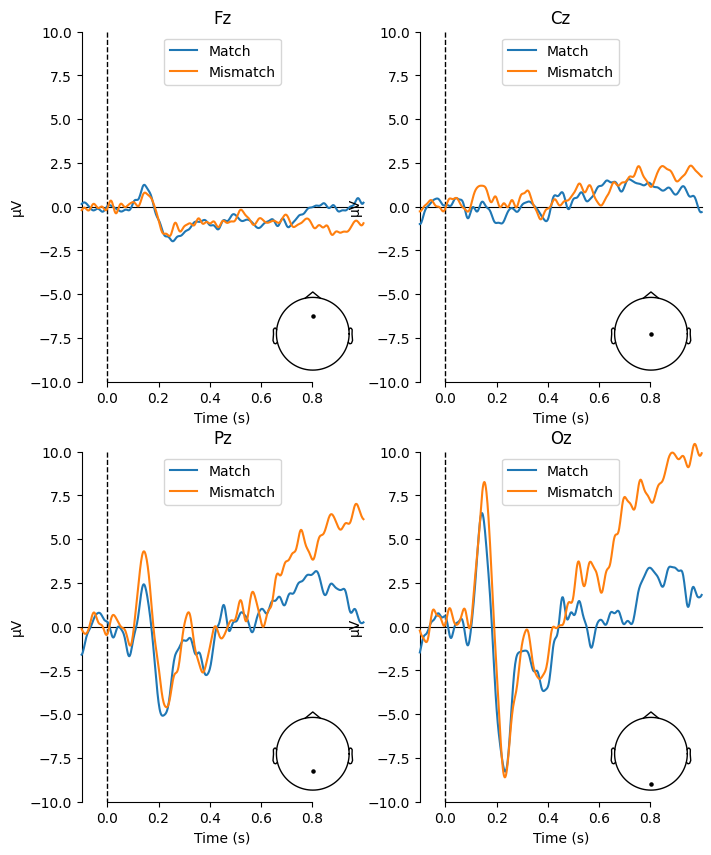

In [ ]:
# define the channels we want plots for
channels = ['Fz', 'Cz', 'Pz', 'Oz']

# create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 10))

# plot each channel in a separate subplot
for idx, chan in enumerate(channels):
    mne.viz.plot_compare_evokeds(evokeds, 
                                picks=chan,
                                ylim={'eeg':(-10, 10)},
                                show_sensors='lower right',
                                legend='upper center',
                                axes=axes.reshape(-1)[idx],
                                show=False
                                );
plt.show()    

In [ ]:
evokeds_avgref = {c:evokeds[c].copy().set_eeg_reference(ref_channels='average') 
                  for c in evokeds.keys()
                  }

In [ ]:
evokeds_mastoidref = {c:evokeds[c].copy().set_eeg_reference(ref_channels=['TP9', 
                                                                          'TP10'
                                                                          ]
                                                            ) 
                      for c in evokeds.keys()
                      }

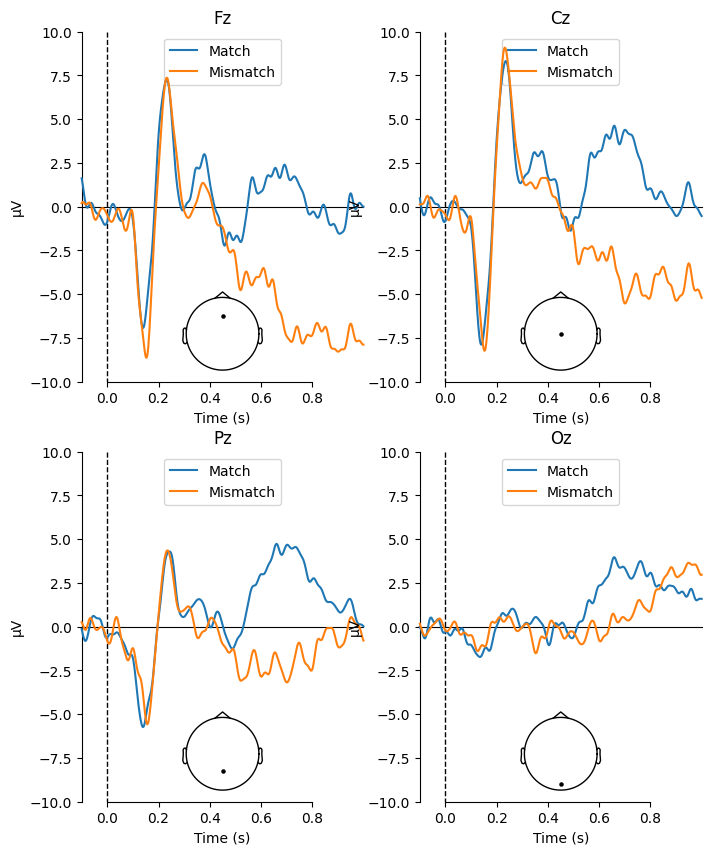

In [ ]:
# create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 10))

# plot each channel in a separate subplot
for idx, chan in enumerate(channels):
    mne.viz.plot_compare_evokeds(evokeds_mastoidref, 
                                picks=chan,
                                ylim={'eeg':(-10, 10)},
                                show_sensors='lower center',
                                legend='upper center',
                                axes=axes.reshape(-1)[idx],
                                show=False
                                );
plt.show()    

## Take-home points

- EEG is a continuous, noisy, time-sensitive signal recorded at the scalp.
- Time-domain and frequency-domain views answer different questions.
- Artifacts are not edge cases; they are a normal part of EEG recording.
- Preprocessing choices matter because they change what signal remains visible.
- In MNE-Python, a useful beginner mental model is `Raw -> Epochs -> Evoked`.
- ERP interpretation depends on timing, polarity, scalp distribution, reference choice, and experimental context.

## Resources

Main sources used for this workshop notebook:

- [Neural Data Science in Python](https://neuraldatascience.io/)
- [What is EEG?](https://neuraldatascience.io/eeg/about-eeg/)
- [Time and Frequency Domains](https://neuraldatascience.io/eeg/time-freq/)
- [Filtering EEG Data](https://neuraldatascience.io/eeg/erp-filtering/)
- [Artifacts in EEG Data](https://neuraldatascience.io/eeg/erp-artifacts/)
- [Exploring MNE's data structure](https://neuraldatascience.io/eeg/mne-data-1/)
- [Segmentation into ERP epochs](https://neuraldatascience.io/eeg/erp-segmentation/)
- [Averaging and Re-Referencing ERPs](https://neuraldatascience.io/eeg/erp-avg-reref/)
- [Event-Related Potentials (ERPs)](https://neuraldatascience.io/eeg/erps/)
- [ERP Components](https://neuraldatascience.io/eeg/components/)
- [MNE documentation homepage](https://mne.tools/stable/index.html)
